# Home Battery Savings Analysis

**Question:** How much would I save over a year if a home battery charged overnight (cheap) and covered all daytime usage, so that *every* kWh is effectively bought at the off-peak rate?

**Tariff — Octopus Intelligent Go**

| Rate | Price | Hours (local time) |
| :--- | :--- | :--- |
| Peak | 30.27p/kWh | 05:00–23:00 |
| Off-peak | 6.9p/kWh | 23:00–05:00 |

**Method**

1. Load one year of half-hourly consumption (1 Jul 2025 – 1 Jul 2026).
2. Label each half-hour as peak or off-peak by its local (Europe/London) start time.
3. Cost each half-hour at the correct rate → **actual annual cost**.
4. Re-cost every half-hour at the off-peak rate → **idealised cost** with a perfect battery.
5. Compare monthly and yearly.

> **Idealised upper bound.** Re-pricing all usage at off-peak assumes a battery large enough to cover every day's daytime load with zero round-trip losses. It is the *maximum* achievable saving; a capacity- and efficiency-constrained simulation (see end) gives a more realistic figure.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Octopus Intelligent Go tariff (£/kWh)
PEAK_RATE = 0.3027       # 05:00–23:00
OFFPEAK_RATE = 0.069     # 23:00–05:00

DATA_DIR = Path("../files") if Path("../files").exists() else Path("files")
CSV_PATH = DATA_DIR / "010725 - 010726 electricity consumption.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Data file:", CSV_PATH)
print("Exists:", CSV_PATH.exists())

Data file: ..\files\010725 - 010726 electricity consumption.csv
Exists: True


## 1. Load and clean the data

Parse timestamps to UTC and convert to `Europe/London` so peak/off-peak is judged on the **local wall-clock hour** (correctly handles the BST/GMT switch).

In [2]:
raw = pd.read_csv(CSV_PATH, skipinitialspace=True)
raw.columns = [c.strip() for c in raw.columns]

df = raw.rename(columns={"Consumption (kwh)": "kwh", "Start": "start", "End": "end"})
df["kwh"] = pd.to_numeric(df["kwh"], errors="coerce")
# ISO8601 handles the mixed fractional seconds in the final row; convert to UK local time
df["start"] = pd.to_datetime(df["start"], format="ISO8601", utc=True).dt.tz_convert("Europe/London")
df["end"] = pd.to_datetime(df["end"], format="ISO8601", utc=True).dt.tz_convert("Europe/London")
df = df.dropna(subset=["kwh"]).sort_values("start").reset_index(drop=True)

# Validation
n = len(df)
dups = int(df["start"].duplicated().sum())
gap = df["start"].diff().dropna()
irregular = int((gap != pd.Timedelta(minutes=30)).sum())
print(f"Rows:                 {n:,}")
print(f"Duplicate starts:     {dups}")
print(f"Non-30-min gaps:      {irregular}  (DST changes expected)")
print(f"Span:                 {df['start'].min()}  ->  {df['start'].max()}")
print(f"Days of data:         {n / 48:.1f}")
print(f"Total consumption:    {df['kwh'].sum():,.1f} kWh")
df.head()

Rows:                 17,568
Duplicate starts:     0
Non-30-min gaps:      0  (DST changes expected)
Span:                 2025-07-01 00:00:00+01:00  ->  2026-07-01 23:30:00+01:00
Days of data:         366.0
Total consumption:    7,573.8 kWh


,kwh,start,end
0,0.137,2025-07-01 00:00:00+01:00,2025-07-01 00:30:00+01:00
1,0.133,2025-07-01 00:30:00+01:00,2025-07-01 01:00:00+01:00
2,0.111,2025-07-01 01:00:00+01:00,2025-07-01 01:30:00+01:00
3,0.109,2025-07-01 01:30:00+01:00,2025-07-01 02:00:00+01:00
4,0.109,2025-07-01 02:00:00+01:00,2025-07-01 02:30:00+01:00


## 2. Label periods and cost each half-hour

Off-peak = start hour in 23:00–05:00 (hours 23, 0, 1, 2, 3, 4); everything else is peak.

In [3]:
hour = df["start"].dt.hour
df["is_offpeak"] = (hour >= 23) | (hour < 5)
df["period"] = df["is_offpeak"].map({True: "off-peak", False: "peak"})
df["rate"] = df["is_offpeak"].map({True: OFFPEAK_RATE, False: PEAK_RATE})

# Split kWh by period for easy aggregation
df["peak_kwh"] = df["kwh"].where(~df["is_offpeak"], 0.0)
df["offpeak_kwh"] = df["kwh"].where(df["is_offpeak"], 0.0)

# Costs
df["actual_cost"] = df["kwh"] * df["rate"]          # current tariff
df["ideal_cost"] = df["kwh"] * OFFPEAK_RATE          # perfect battery: all off-peak

df[["start", "kwh", "period", "rate", "actual_cost", "ideal_cost"]].head()

,start,kwh,period,rate,actual_cost,ideal_cost
0,2025-07-01 00:00:00+01:00,0.137,off-peak,0.069,0.009453,0.009453
1,2025-07-01 00:30:00+01:00,0.133,off-peak,0.069,0.009177,0.009177
2,2025-07-01 01:00:00+01:00,0.111,off-peak,0.069,0.007659,0.007659
3,2025-07-01 01:30:00+01:00,0.109,off-peak,0.069,0.007521,0.007521
4,2025-07-01 02:00:00+01:00,0.109,off-peak,0.069,0.007521,0.007521


## 3. Yearly totals and headline saving

In [4]:
total_kwh = df["kwh"].sum()
peak_kwh = df["peak_kwh"].sum()
offpeak_kwh = df["offpeak_kwh"].sum()
actual_cost = df["actual_cost"].sum()
ideal_cost = df["ideal_cost"].sum()
saving = actual_cost - ideal_cost

print("=== Consumption ===")
print(f"Total:                  {total_kwh:>10,.1f} kWh")
print(f"Peak (05:00-23:00):     {peak_kwh:>10,.1f} kWh  ({peak_kwh / total_kwh:.1%})")
print(f"Off-peak (23:00-05:00): {offpeak_kwh:>10,.1f} kWh  ({offpeak_kwh / total_kwh:.1%})")
print()
print("=== Annual cost ===")
print(f"Actual (current tariff):         £{actual_cost:>9,.2f}")
print(f"Idealised (all @ 6.9p off-peak): £{ideal_cost:>9,.2f}")
print(f"Saving:                          £{saving:>9,.2f}  ({saving / actual_cost:.1%})")
print()
print(f"Blended actual rate: {actual_cost / total_kwh * 100:.2f} p/kWh  ->  off-peak {OFFPEAK_RATE * 100:.2f} p/kWh")

=== Consumption ===
Total:                     7,573.8 kWh
Peak (05:00-23:00):        5,486.9 kWh  (72.4%)
Off-peak (23:00-05:00):    2,086.9 kWh  (27.6%)

=== Annual cost ===
Actual (current tariff):         £ 1,804.88
Idealised (all @ 6.9p off-peak): £   522.59
Saving:                          £ 1,282.28  (71.0%)

Blended actual rate: 23.83 p/kWh  ->  off-peak 6.90 p/kWh


## 4. Monthly breakdown

In [5]:
monthly = (
    df.set_index("start")
    .resample("MS")
    .agg(
        total_kwh=("kwh", "sum"),
        peak_kwh=("peak_kwh", "sum"),
        offpeak_kwh=("offpeak_kwh", "sum"),
        actual_cost=("actual_cost", "sum"),
        ideal_cost=("ideal_cost", "sum"),
    )
)
monthly["saving"] = monthly["actual_cost"] - monthly["ideal_cost"]
monthly["peak_pct"] = monthly["peak_kwh"] / monthly["total_kwh"]

table = monthly.copy()
table.index = table.index.strftime("%b %Y")
table.columns = ["Total kWh", "Peak kWh", "Off-pk kWh", "Actual £", "Ideal £", "Saving £", "Peak %"]
table.round({"Total kWh": 1, "Peak kWh": 1, "Off-pk kWh": 1,
            "Actual £": 2, "Ideal £": 2, "Saving £": 2, "Peak %": 3})

,Total kWh,Peak kWh,Off-pk kWh,Actual £,Ideal £,Saving £,Peak %
start,,,,,,,
Jul 2025,648.8,496.6,152.2,160.83,44.77,116.07,0.765
Aug 2025,507.7,404.3,103.4,129.52,35.03,94.49,0.796
Sep 2025,560.3,430.2,130.1,139.20,38.66,100.54,0.768
Oct 2025,712.5,461.3,251.2,156.97,49.16,107.81,0.647
Nov 2025,673.4,477.1,196.3,157.98,46.47,111.51,0.709
Dec 2025,780.3,558.6,221.6,184.39,53.84,130.55,0.716
Jan 2026,722.6,505.3,217.4,167.94,49.86,118.08,0.699
Feb 2026,612.2,418.9,193.3,140.13,42.24,97.89,0.684
Mar 2026,637.5,426.3,211.3,143.61,43.99,99.62,0.669


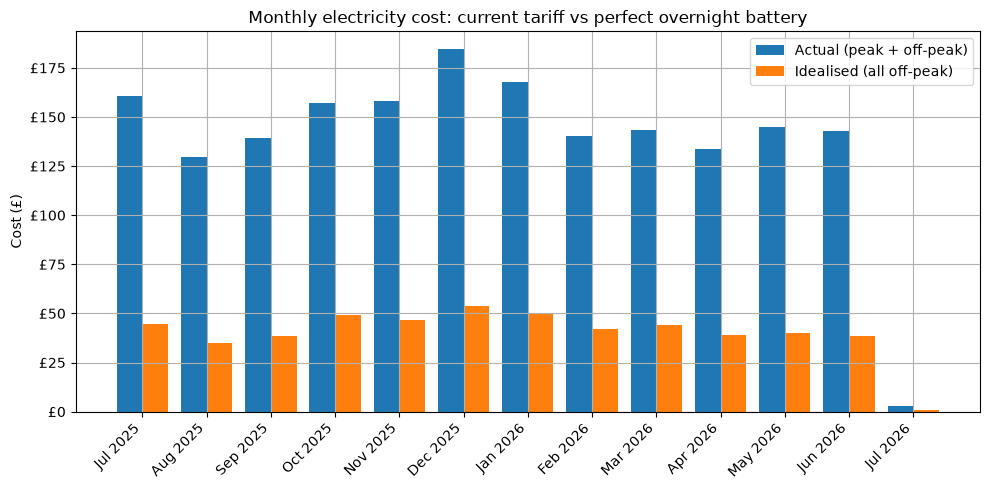

In [6]:
labels = monthly.index.strftime("%b %Y")

fig, ax = plt.subplots()
x = range(len(monthly))
width = 0.4
ax.bar([i - width / 2 for i in x], monthly["actual_cost"], width, label="Actual (peak + off-peak)")
ax.bar([i + width / 2 for i in x], monthly["ideal_cost"], width, label="Idealised (all off-peak)")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Cost (£)")
ax.set_title("Monthly electricity cost: current tariff vs perfect overnight battery")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("£%.0f"))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_cost_comparison.png", dpi=120)
plt.show()

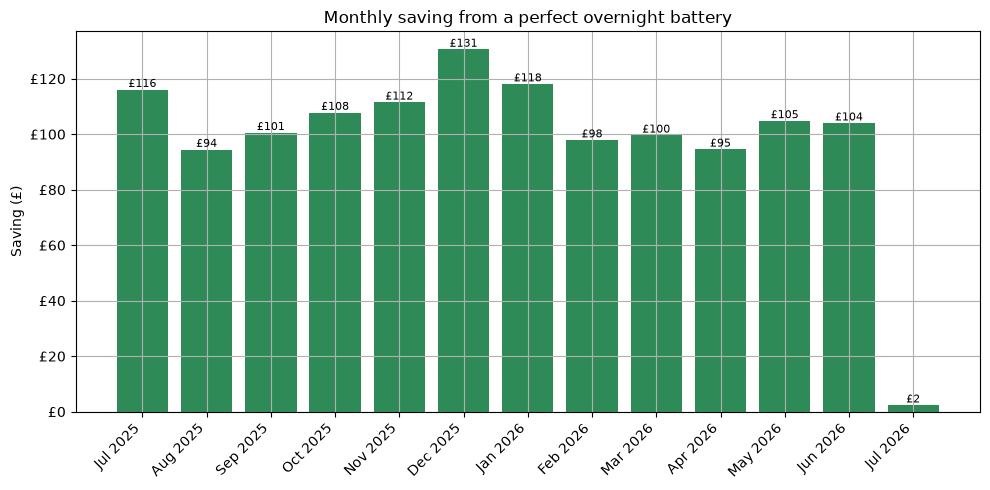

In [8]:
fig, ax = plt.subplots()
ax.bar(labels, monthly["saving"], color="seagreen")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylabel("Saving (£)")
ax.set_title("Monthly saving from a perfect overnight battery")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("£%.0f"))
for i, v in enumerate(monthly["saving"]):
    ax.text(i, v, f"£{v:.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_savings.png", dpi=120)
plt.show()

## 5. When is the energy used? Average daily profile

Where consumption sits across the day drives the saving: load in the shaded off-peak window is already cheap, so the opportunity is the daytime peak.

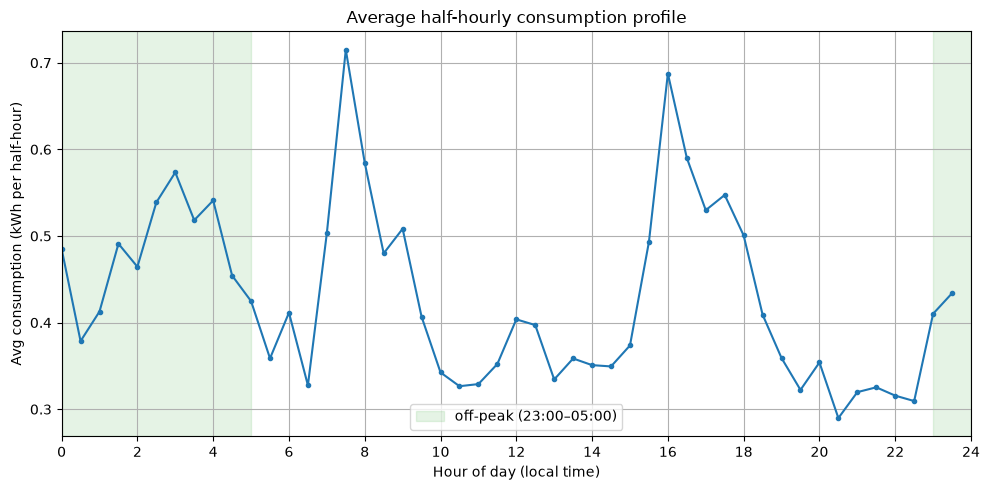

In [9]:
prof = df.assign(hour_dec=df["start"].dt.hour + df["start"].dt.minute / 60)
avg = prof.groupby("hour_dec")["kwh"].mean()

fig, ax = plt.subplots()
ax.plot(avg.index, avg.values, marker=".")
ax.axvspan(0, 5, color="tab:green", alpha=0.12, label="off-peak (23:00–05:00)")
ax.axvspan(23, 24, color="tab:green", alpha=0.12)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Avg consumption (kWh per half-hour)")
ax.set_title("Average half-hourly consumption profile")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "daily_profile.png", dpi=120)
plt.show()

## Notes and further analysis

**This model is an idealised upper bound.** It assumes a battery that can store enough each night to cover the *entire* next-day load with no round-trip losses. Real savings will be lower. Natural next steps, in rough priority:

1. **Capacity- and efficiency-constrained simulation** — step through each half-hour with a fixed usable capacity (e.g. 20.7 kWh), a charge-power limit, and ~90% round-trip efficiency. Days that exceed capacity still import some peak energy → realistic saving and the "right" battery size.
2. **Payback vs battery size** — sweep capacity (5–30 kWh) and plot annual saving and simple payback against the installed cost, to find the sweet spot.
3. **Seasonality** — winter vs summer saving (heating/daylight effects already visible in the monthly chart).
4. **Load-duration & peak-demand** — how often daytime draw exceeds the inverter power limit (e.g. 6 kW).
5. **Export arbitrage** — if on Outgoing Octopus, value overnight-charged energy exported during the day.

**Display recommendation:** keep this notebook as the exploratory surface (code + charts + narrative in one place), and once figures settle, promote a short summary + the saved PNGs in `outputs/` into the README or the main report.